# Lesson 15 — Logistic Regression: Predicting a Category

**What this notebook does:** builds a classifier from scratch — a model that predicts a **yes/no category** instead of a number. It is linear regression plus one extra step: we take the same weighted sum `w * x + b`, squash it through the **sigmoid** into a probability between 0 and 1, and then make a yes/no decision.

We go step by step:
1. Meet the **sigmoid** — the gate that turns any number into a probability.
2. Look at the data: one number per ticket (how many urgency-signal words it has) and a 0/1 label.
3. Write the model `P(urgent) = sigmoid(w * x + b)`.
4. Score it with **log loss** (why not mean squared error).
5. Train with gradient descent — almost identical to last lesson's loop.
6. Read the probabilities, find the **decision boundary**, and plot the S-curve.
7. Turn probabilities into yes/no decisions and measure accuracy.

## Step 1 — The sigmoid: turning any number into a probability

A weighted sum `w * x + b` can be any number at all — huge positive, huge negative. But a probability must sit between 0 and 1. The **sigmoid** is the gate that squashes any number into that range.

Plain meaning: a big **positive** input comes out near **1** ("almost certainly yes"), a big **negative** input comes out near **0** ("almost certainly no"), and **0** comes out at exactly **0.5** ("a coin flip"). It bends smoothly between, so you always get a graded confidence, never a hard 0 or 1.

In symbols (meaning first, above): `sigmoid(z) = 1 / (1 + e^(-z))`. We write it carefully so a big input never overflows `e`.

In [ ]:
import math

def sigmoid(z):
    # Squash any number z into a probability between 0 and 1.
    # Big positive z -> near 1; big negative z -> near 0; z = 0 -> exactly 0.5.
    if z < 0:
        # Rewrite the formula so math.exp never overflows on large positive inputs.
        return math.exp(z) / (1.0 + math.exp(z))
    else:
        return 1.0 / (1.0 + math.exp(-z))

# See the S-shaped squash at a few inputs.
for z in [-6, -2, 0, 2, 6]:
    print(f'sigmoid({z:>3}) = {sigmoid(z):.3f}')

sigmoid( -6) = 0.002
sigmoid( -2) = 0.119
sigmoid(  0) = 0.500
sigmoid(  2) = 0.881
sigmoid(  6) = 0.998


: 

**Why the `if z < 0` split?** It is a numerical-stability trick, not new math. The two lines are the *same* formula: multiply the top and bottom of `1 / (1 + e^(-z))` by `e^z` and you get `e^z / (1 + e^z)` — identical values for every `z`.

They differ only in *which exponent* they hand to `math.exp`, and `math.exp(big positive number)` overflows (`math.exp(710)` already errors), while `math.exp(big negative number)` is safe (it just returns ≈ 0):

- `1 / (1 + e^(-z))` feeds `-z` to `exp` — dangerous when `z` is large **negative** (`-z` becomes large positive → overflow).
- `e^z / (1 + e^z)` feeds `z` to `exp` — dangerous when `z` is large **positive**.

So the code picks whichever form is safe for the sign of `z`. The result: in **both** branches the number handed to `math.exp` is `≤ 0`, so it always returns a value in `(0, 1]` and never overflows — even when the weighted sum `w*x + b` grows to something like `-800` (which correctly gives `P ≈ 0`).

## Step 2 — The data: one number per ticket, plus a yes/no label

To keep the picture clear we reduce each past ticket to a **single number**: how many *urgency-signal* words it contains — words like `now`, `immediately`, `asap`, `cannot`, `right`, `today`. The label is **1** for urgent, **0** for not urgent.

Notice the **overlap** around 1–3 signal words: some are urgent, some are not. The signal count *leans* the odds, it does not decide with certainty — which is exactly what a probability is for. (One number is a teaching simplification; real classifiers use many features. Turning raw text into good features is Chapter 6.)

In [3]:
# Each past ticket reduced to ONE number: its count of urgency-signal words (x),
# paired with the human label (y): 1 = urgent, 0 = not urgent.
signal_counts = [0, 0, 1, 1, 1, 2, 2, 3, 3, 4, 4, 5]   # the single feature x
labels        = [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1]   # the answer y (1 = urgent)

# Show the pairs so the overlap around 1-3 signal words is visible.
print('signal_count(x)   urgent?(y)')
for i in range(len(signal_counts)):
    print(f'       {signal_counts[i]}               {labels[i]}')
print()
print('Number of tickets:', len(signal_counts))

signal_count(x)   urgent?(y)
       0               0
       0               0
       1               0
       1               1
       1               0
       2               1
       2               1
       3               1
       3               0
       4               1
       4               1
       5               1

Number of tickets: 12


## Step 3 — The model: a weighted sum, then the sigmoid

The model is one line: `P(urgent) = sigmoid(w * x + b)`. The inside part `w * x + b` is the same weighted sum as linear regression — it is called the **logit** (the raw score before squashing). The sigmoid turns that raw score into a probability.

Below we write it as a function and try a rough guess model, so we can feel how an untrained classifier behaves.

In [4]:
def predict_prob(w, b, x):
    # The model: push the weighted sum through the sigmoid to get P(urgent).
    z = w * x + b            # the logit: same weighted sum as linear regression
    return sigmoid(z)        # squashed into a 0..1 probability

# Try a rough guess model and read off its probabilities.
guess_w = 0.5                # a gentle upward slope
guess_b = 0.0               # no offset
print(f'Guess model: P(urgent) = sigmoid({guess_w} * x + {guess_b})')
print()
print(' x   P(urgent)   actual')
for i in range(len(signal_counts)):
    x = signal_counts[i]                     # this ticket's signal count
    actual = labels[i]                       # its true 0/1 label
    p = predict_prob(guess_w, guess_b, x)    # what the guess model believes
    print(f'{x:>2}     {p:.3f}      {actual}')

Guess model: P(urgent) = sigmoid(0.5 * x + 0.0)

 x   P(urgent)   actual
 0     0.500      0
 0     0.500      0
 1     0.622      0
 1     0.622      1
 1     0.622      0
 2     0.731      1
 2     0.731      1
 3     0.818      1
 3     0.818      0
 4     0.881      1
 4     0.881      1
 5     0.924      1


## Step 4 — Scoring a classifier: log loss (not MSE)

For classification we do **not** use mean squared error. We use **log loss** (also called **cross-entropy**).

Plain meaning: for a ticket that is truly **urgent** (`y = 1`), we want `P` near 1, so we penalise it by `-log(P)` — almost nothing when `P` is near 1, but a huge, exploding penalty if the model confidently said `P` near 0. For a ticket that is truly **not urgent** (`y = 0`), we penalise `-log(1 - P)` instead. In one sentence: **log loss rewards confident-correct answers and punishes confident-wrong answers hard** — exactly the incentive a probability needs.

Worked example: a truly-urgent ticket. If the model says `P = 0.9`, its loss is `-log(0.9) = 0.105` (small). If it says `P = 0.1`, its loss is `-log(0.1) = 2.303` (over 20x worse). Same wrongness in raw distance, but far harsher when it was confident and wrong.

In [5]:
def log_loss(w, b):
    # Average penalty across all tickets. Confident-and-wrong is punished hard.
    total_loss = 0.0                          # running sum of per-ticket penalties
    for i in range(len(signal_counts)):
        x = signal_counts[i]                  # this ticket's signal count
        actual = labels[i]                    # its true 0/1 label
        p = predict_prob(w, b, x)             # the model's probability of urgent
        # Keep p just inside (0, 1) so log never blows up on an exact 0 or 1.
        if p < 1e-9:
            p = 1e-9
        if p > 1 - 1e-9:
            p = 1 - 1e-9
        if actual == 1:                       # truly urgent: we wanted p near 1
            point_loss = -math.log(p)
        else:                                 # truly not urgent: we wanted p near 0
            point_loss = -math.log(1.0 - p)
        total_loss += point_loss              # add this ticket's penalty
    return total_loss / len(signal_counts)    # average over all tickets

# The guess model's log loss: a number we now want to push down by training.
print(f'Log loss of the guess model: {log_loss(guess_w, guess_b):.3f}')

Log loss of the guess model: 0.556


## Step 5 — Training: gradient descent, almost unchanged

Here is the pleasant surprise. When you pair the **sigmoid** with **log loss**, the two slopes come out in the *same clean shape* as linear regression (the messy sigmoid derivative and the messy log derivative cancel out):

- **Slope for `w`** = average of `(P − actual) * x`
- **Slope for `b`** = average of `(P − actual)`

where `P` is the predicted probability and `actual` is the true 0 or 1. So the training loop is the one you already know: measure both slopes, step both knobs a little downhill, repeat. Watch the log loss fall.

### Why those two slopes come out so clean (the messy pieces cancel)

The clean shape is not luck — it is the reason the sigmoid and log loss are always used *together*. Here it is in plain steps, using the **chain rule** from Lesson 14 (multiply the slope of each link in the chain):

```
w  ──►  z = w*x + b  ──►  P = sigmoid(z)  ──►  L = log loss
```

The two middle links look scary alone, but they undo each other:

- **The sigmoid's slope is tidy:** the rate `P` changes as `z` changes is exactly `P * (1 - P)`. (Check it against the S-shape: steepest in the middle where `P ≈ 0.5` gives `0.5 * 0.5 = 0.25`; flat at the ends where `P ≈ 0` or `1` gives `≈ 0`.) This factor sits on **top**.
- **The log loss's slope is where the mess is:** the slope of `log(P)` is `1/P`, so log loss's slope with respect to `P` leaves `P` and `(1 - P)` on the **bottom** of a fraction — the part that would blow up near 0 or 1.

Multiply the links (chain rule) and the top cancels the bottom:

```
   P * (1 - P)   (from the sigmoid)
   ───────────────────────────────  × (label bits)   ⟶   P - y
   P   and  (1 - P)   (from the log)
```

All that survives is `P - y` (predicted probability minus the true 0/1). Times the last link `x`, per point:

```
slope for w  =  (P - y) * x
slope for b  =  (P - y)
```

...which is exactly what `compute_gradients` below computes. **Concrete feel:** a truly-urgent ticket (`y = 1`) rated `P = 0.9` gets a slope of `0.9 - 1 = -0.1` (small nudge, nearly right); a confidently-wrong one rated `P = 0.1` gets `0.1 - 1 = -0.9` — nine times the push. Pair the sigmoid with mean squared error instead and the `P * (1 - P)` would *not* cancel; near `P ≈ 0` or `1` it makes the gradient vanish and learning stalls — which is why sigmoid + log loss are a matched pair.

In [6]:
def compute_gradients(w, b):
    # Same shape as linear regression: average of (prediction - actual), and the
    # w-slope weights each error by x. Here 'prediction' is a probability.
    w_slope_total = 0.0                       # running sum for the w-slope
    b_slope_total = 0.0                       # running sum for the b-slope
    n = len(signal_counts)                    # number of tickets
    for i in range(n):
        x = signal_counts[i]                  # this ticket's signal count
        actual = labels[i]                    # its true 0/1 label
        p = predict_prob(w, b, x)             # predicted probability of urgent
        error = p - actual                    # probability minus the true 0/1
        w_slope_total += error * x            # weight the error by x for w
        b_slope_total += error                # plain error for b
    w_slope = w_slope_total / n               # average -> the w-slope
    b_slope = b_slope_total / n               # average -> the b-slope
    return w_slope, b_slope

# Train: start at zero, step both knobs downhill on the log loss, many times.
w = 0.0                                       # start the weight at 0
b = 0.0                                       # start the bias at 0
learning_rate = 0.3                           # step size
iterations = 3000                             # how many nudges to take

for step in range(iterations):                # one nudge per loop
    w_slope, b_slope = compute_gradients(w, b)   # which way is downhill
    w = w - learning_rate * w_slope           # step w against its slope
    b = b - learning_rate * b_slope           # step b against its slope
    if step % 300 == 0:                       # print progress now and then
        print(f'step {step:>4}:  w={w:6.3f}  b={b:7.3f}  loss={log_loss(w, b):.4f}')

print()
print(f'Trained model: P(urgent) = sigmoid({w:.3f} * x + {b:.3f})')
print(f'Final log loss: {log_loss(w, b):.4f}')

step    0:  w= 0.200  b=  0.025  loss=0.5954
step  300:  w= 1.206  b= -1.939  loss=0.4412
step  600:  w= 1.227  b= -1.985  loss=0.4411
step  900:  w= 1.227  b= -1.986  loss=0.4411
step 1200:  w= 1.227  b= -1.986  loss=0.4411
step 1500:  w= 1.227  b= -1.986  loss=0.4411
step 1800:  w= 1.227  b= -1.986  loss=0.4411
step 2100:  w= 1.227  b= -1.986  loss=0.4411
step 2400:  w= 1.227  b= -1.986  loss=0.4411
step 2700:  w= 1.227  b= -1.986  loss=0.4411

Trained model: P(urgent) = sigmoid(1.227 * x + -1.986)
Final log loss: 0.4411


## Step 6 — Reading the model and its decision boundary

The trained model is again just two numbers, `w` and `b`. From them we can find the **decision boundary**: the signal count where the model is exactly 50/50. Since `P = 0.5` happens exactly when `w * x + b = 0`, solving gives `x = -b / w`.

Below that boundary the model leans "not urgent"; above it, "urgent". The probability rises smoothly through the boundary rather than flipping suddenly — that graded confidence is the whole point of logistic regression.

In [7]:
# Read the probability the model assigns at each signal count.
print(' x   P(urgent)')
for x in [0, 1, 2, 3, 4, 5]:
    print(f'{x:>2}    {predict_prob(w, b, x):.3f}')

# Decision boundary: the x where P = 0.5, i.e. where w*x + b = 0  ->  x = -b / w.
boundary = -b / w
print()
print(f'Decision boundary at x = {boundary:.2f} signal words')
print('Below that -> leans NOT urgent; above -> leans urgent.')

 x   P(urgent)
 0    0.121
 1    0.319
 2    0.615
 3    0.845
 4    0.949
 5    0.984

Decision boundary at x = 1.62 signal words
Below that -> leans NOT urgent; above -> leans urgent.


## Step 7 — See the S-curve

A picture makes it obvious. We draw the smooth `P(urgent)` curve, scatter the real tickets (all sitting at height 0 or 1), and mark the decision boundary. A good model has its S-curve rising from the cluster of 0-labelled tickets on the left up to the 1-labelled tickets on the right. The image is also saved as a PNG under `plots/`.

Saved: plots/lesson-15-sigmoid-curve.png


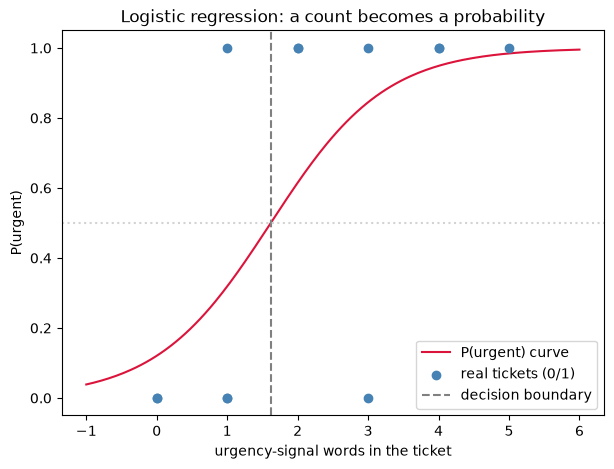

In [8]:
import matplotlib.pyplot as plt              # the plotting library
import numpy as np                           # for a smooth range of x-values
import os                                    # to make a folder for the image

# A smooth line of x-values to draw the S-curve through.
curve_x = np.linspace(-1, 6, 200)            # 200 points from -1 to 6
curve_y = []                                 # matching P(urgent) for each
for x in curve_x:                            # walk along the x-axis
    curve_y.append(predict_prob(w, b, x))    # model's probability at that x

plt.figure(figsize=(7, 5))                   # a fresh canvas
plt.plot(curve_x, curve_y, color='crimson', label='P(urgent) curve')
plt.scatter(signal_counts, labels, color='steelblue', zorder=3, label='real tickets (0/1)')
plt.axvline(boundary, color='gray', linestyle='--', label='decision boundary')
plt.axhline(0.5, color='lightgray', linestyle=':')   # the 50/50 line
plt.xlabel('urgency-signal words in the ticket')
plt.ylabel('P(urgent)')
plt.title('Logistic regression: a count becomes a probability')
plt.legend()

os.makedirs('plots', exist_ok=True)          # make a plots/ folder if missing
plt.savefig('plots/lesson-15-sigmoid-curve.png', dpi=120)   # save the picture
print('Saved: plots/lesson-15-sigmoid-curve.png')
plt.show()                                   # display it in the notebook

## Step 8 — From probability to a yes/no decision

The probability is the honest output, but often we still need to *act* — urgent or not. We apply a **threshold**: the usual choice is 0.5. Then we can check how many of the tickets the model gets right, and compare it to the dumbest possible baseline: always guess the more common class.

(0.5 is only a default. If missing an urgent ticket is far worse than a false alarm, you would lower the threshold so more tickets get flagged — metrics like precision and recall, in Chapter 7, make that trade-off precise.)

In [9]:
def classify(x):
    # Turn the probability into a yes/no using the 0.5 threshold.
    p = predict_prob(w, b, x)
    if p >= 0.5:
        return 1                             # urgent
    else:
        return 0                             # not urgent

# Count how many of the 12 tickets the trained model classifies correctly.
correct = 0                                  # running tally of right answers
for i in range(len(signal_counts)):
    predicted_label = classify(signal_counts[i])   # model's yes/no
    if predicted_label == labels[i]:               # compare to the truth
        correct += 1
accuracy = correct / len(signal_counts)      # fraction right

# Baseline to beat: always guess whichever class is more common.
urgent_total = 0                             # how many tickets are urgent
for y in labels:
    if y == 1:
        urgent_total += 1
not_urgent_total = len(labels) - urgent_total
if urgent_total > not_urgent_total:          # the bigger pile
    majority_count = urgent_total
else:
    majority_count = not_urgent_total
baseline = majority_count / len(labels)      # accuracy of always-guess-majority

print(f'Model accuracy on the 12 tickets: {accuracy:.2f}')
print(f'Majority-class baseline:          {baseline:.2f}')

Model accuracy on the 12 tickets: 0.83
Majority-class baseline:          0.58


**Compact alternative (same result):** the two counting loops above each have an idiomatic one-line form worth recognizing later. We keep the plain loops as the version that runs, but in real Python you will often see:

```python
correct = sum(1 for i in range(len(signal_counts)) if classify(signal_counts[i]) == labels[i])
urgent_total = sum(labels)          # labels are 0/1, so summing counts the 1s
majority_count = max(urgent_total, len(labels) - urgent_total)
```

## Recap — what we just built

- **Logistic regression is linear regression plus a sigmoid:** the same `w * x + b`, squashed into a probability between 0 and 1.
- We scored it with **log loss**, which punishes confident-wrong answers hard — the right incentive for a probability (mean squared error is for numbers).
- Training was **gradient descent** again, and thanks to the sigmoid+log-loss pairing the slopes had the same clean shape as last lesson: average of `(P − actual)`, weighted by `x` for the weight.
- The trained model is still just **two numbers**, and its **decision boundary** sits at `x = -b / w` — the count where it is exactly 50/50.
- Unlike the old hand-written rule, this model **learned** its boundary from the labels and outputs a **calibrated confidence**, not just a flat yes/no.